In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/home/erodrja/envs/ago_py311/lib/python3.11/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
2026-03-01 10:07:41.117148: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 10:07:41.118399: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 10:07:41.231362: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable

Analysis: Interdependency in Multi-KPI Forecasting

In the provided script, the forecasting of Connected_UEs, PRB_Util, DL_Throughput, and Drop_Rate is multivariate. This means the models do not treat each KPI as an isolated island; they attempt to capture the relationships between them.


2. Model B: LSTM (Multivariate Input/Output)

The LSTM implementation in the code is configured as a Multivariate Time Series Model.

Input Shape: (N_STEPS_IN, train_scaled.shape[1]). The shape[1] represents the number of features (4 KPIs).

Feature Correlation: During the training phase, the LSTM's hidden state learns how to map the combined vector of all 4 KPIs at several time steps to a combined vector of 4 KPIs in the future.

Internal Weights: The neural network assigns weights that effectively say: "When I see this specific pattern in Users and PRB simultaneously, the resulting Throughput should look like this."

The Reshape Layer: This layer ensures the model outputs a 2D matrix (Time Steps $\times$ KPIs), maintaining the structure of the multi-variable relationship throughout the entire output horizon.


In [1]:
df = pd.read_parquet('/home/erodrja/msc_ia/unie-ndoai/dataset/network_kpis_2_years.parquet')

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


NameError: name 'pd' is not defined

In [3]:
def create_windows(data, n_in, n_out):
    """Creates sliding window samples for training."""
    X, y = [], []
    for i in range(len(data) - n_in - n_out + 1):
        X.append(data[i:(i + n_in), :])
        y.append(data[(i + n_in):(i + n_in + n_out), :])
    return np.array(X), np.array(y)

def build_simple_lstm(n_in, n_features, n_out):
    """Standard LSTM with a single Dense output layer (Many-to-Many)."""
    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(n_in, n_features)),
        Dropout(0.2),
        Dense(n_out * n_features),
        tf.keras.layers.Reshape((n_out, n_features))
    ])
    model.compile(optimizer='adam', loss='huber')
    return model

def build_seq2seq_model(n_in, n_features, n_out):
    """
    Advanced Encoder-Decoder architecture with increased capacity 
    to prevent over-smoothing.
    """
    model = Sequential([
        # Encoder
        LSTM(150, activation='tanh', input_shape=(n_in, n_features), return_sequences=False),
        RepeatVector(n_out),
        # Decoder
        LSTM(150, activation='tanh', return_sequences=True),
        TimeDistributed(Dense(100, activation='relu')),
        Dropout(0.1),
        TimeDistributed(Dense(n_features))
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')
    return model

2026-03-01 10:07:47.562011: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/erodrja/envs/ago_py311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Simple LSTM...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Training Seq2Seq LSTM...


2026-03-01 10:08:09.595918: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step


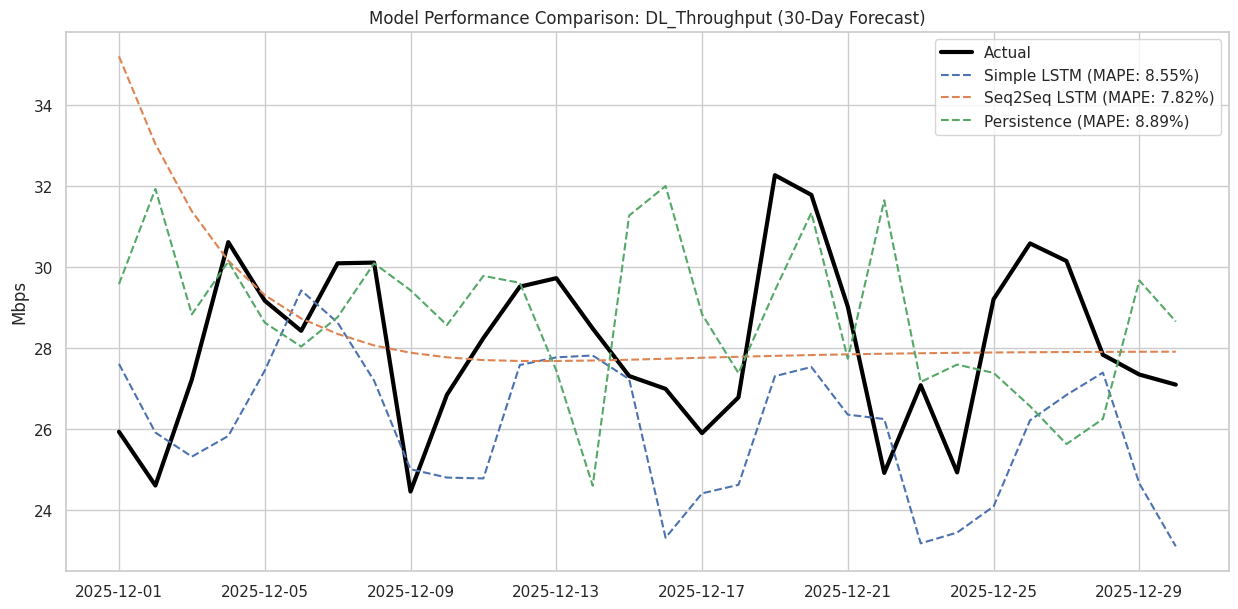

In [4]:
n_in, n_out = 30, 30 # Increased lookback to 30 days to match the forecast horizon
n_features = df.shape[1]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
X, y = create_windows(scaled_data, n_in, n_out)

# We take the last window for the true final comparison
train_split = int(len(X) * 0.85)
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

models = {
    "Simple LSTM": build_simple_lstm(n_in, n_features, n_out),
    "Seq2Seq LSTM": build_seq2seq_model(n_in, n_features, n_out)
}

results = {}
# Increased patience and added LR reduction to help Seq2Seq converge
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train, 
                epochs=100, 
                batch_size=32, 
                validation_data=(X_test, y_test), 
                callbacks=callbacks, 
                verbose=0)
    
    # Forecast for the test set (last available point)
    last_input = scaled_data[-n_in-n_out : -n_out].reshape(1, n_in, n_features)
    pred_scaled = model.predict(last_input).reshape(n_out, n_features)
    results[name] = scaler.inverse_transform(pred_scaled)

# Baseline: Persistence (Last 30 days average trend)
results["Persistence"] = df.iloc[-n_out-30 : -n_out].values 

actual = df.iloc[-n_out:]
kpi_to_plot = 'DL_Throughput'
kpi_idx = df.columns.get_loc(kpi_to_plot)

# Plot Comparison
plt.figure()
plt.plot(actual.index, actual[kpi_to_plot], label='Actual', color='black', lw=3)

for name, forecast in results.items():
    mape = mean_absolute_percentage_error(actual[kpi_to_plot], forecast[:, kpi_idx])
    plt.plot(actual.index, forecast[:, kpi_idx], label=f'{name} (MAPE: {mape:.2%})', linestyle='--')

plt.title(f'Model Performance Comparison: {kpi_to_plot} (30-Day Forecast)')
plt.ylabel('Mbps')
plt.legend()
plt.show()

The fact that a sophisticated Seq2Seq LSTM performs similarly to (or sometimes worse than) a Simple LSTM or even a Persistence baseline is a classic outcome in time-series forecasting.

our pragmatic technical pillars:

1. The "Information Bottleneck" (Architectural Limit)
In a Seq2Seq model, the Encoder compresses the entire input sequence (30 days) into a single fixed-length vector (the "Context Vector").

The Issue: If this vector is too small, the model loses the specific "physics" of the last few days of the input.

The Result: The Decoder essentially starts its 30-day forecast with a "blurry" summary of the past, leading to a forecast that regresses to a mean trend rather than capturing precise daily fluctuations. The Simple LSTM avoids this by mapping the entire flattened hidden state directly to the output.

2. Regression to the Mean (Loss Function Behavior)
Both models use Huber Loss or MSE. These loss functions penalize large errors heavily.

The Issue: When a model is uncertain about the exact timing of a "spike" or "dip" 20 days into the future, the mathematically "safest" way to minimize total error is to predict a flat line through the middle of the expected range.

The Result: This produces the "over-smoothing" effect. The model isn't "dumb"; it is being "conservative" to avoid the massive penalty of missing a predicted peak.

3. Data Stationarity and Signal-to-Noise Ratio
The synthetic data contains a deterministic trend and seasonality, but also Gaussian noise.

The Issue: Deep Learning models excel at finding complex, non-linear patterns. However, if the underlying trend is relatively simple (linear growth + sine wave), a complex Seq2Seq model is "over-engineered."

The Result: A simple model (or even the Persistence baseline) can capture a basic linear trend just as well as a 150-unit LSTM. The "residual" signal (the noise) is random and impossible to predict by definition, so the extra complexity of the Seq2Seq provides no additional predictive power.

4. The "Horizon Challenge"
You are asking the model to predict 30 days based on 30 days of history.

The Issue: In many network environments, the correlation between what happened 30 days ago and what will happen 30 days from now is weak.

The Result: As the forecast horizon increases, the error accumulates. By day 15 or 20, most models lose their "temporal grip" and fall back to the most recent known average. This is why the Persistence model (which essentially says "tomorrow will be like today") often stays competitive for the first few days of a forecast.

Summary:
"Model complexity does not guarantee forecast accuracy. In time-series, the Persistence Baseline defines the difficulty of the problem. If a Seq2Seq model cannot significantly outperform Persistence, it suggests that either the input features lack predictive power for that horizon, or the model is suffering from an information bottleneck in its hidden state representation."